# Germany and EU Tourism Competitiveness Analysis
## 04 - Statistical Analysis

### Purpose

This notebook applies formal statistical methods to investigate relationships and patterns identified during exploratory data analysis.

The statistical analysis focuses on questions that are both methodologically appropriate and relevant to Germany's tourism competitiveness.

The main objectives are to:

- evaluate whether Germany's international average length of stay shows a significant downward trend over time
- examine the relationship between source-market size and average stay duration
- examine the relationship between recent source-market growth and average stay duration
- evaluate differences in tourism behavior where statistically appropriate
- assess statistical assumptions before selecting each test
- calculate and interpret test statistics, p-values, confidence intervals, and effect sizes where appropriate
- identify critical values and rejection regions for hypothesis decisions
- distinguish statistical significance from practical and business significance

A significance level of **α = 0.05** will be used unless otherwise specified.

Statistical results will be interpreted as evidence of association or difference and will not be treated as proof of causation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from scipy import stats
from scipy.stats import (
    shapiro,
    pearsonr,
    spearmanr,
    linregress
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Statistical analysis libraries imported successfully.")

Statistical analysis libraries imported successfully.


In [2]:
project_root = Path.cwd().parent

clean_path = project_root / "data" / "clean"
processed_path = project_root / "data" / "processed"
figures_path = project_root / "figures"

figures_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", project_root)
print("Clean data:", clean_path)
print("Processed data:", processed_path)
print("Figures:", figures_path)

Project root: /Users/jannoelvero/Documents/germany_eu_tourism_analysis
Clean data: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/data/clean
Processed data: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/data/processed
Figures: /Users/jannoelvero/Documents/germany_eu_tourism_analysis/figures


In [3]:
germany_arrivals = pd.read_csv(
    clean_path /
    "germany_foreign_arrivals_monthly_clean.csv",
    parse_dates=["date"]
)

germany_nights = pd.read_csv(
    clean_path /
    "germany_foreign_nights_monthly_clean.csv",
    parse_dates=["date"]
)

source_arrivals = pd.read_csv(
    clean_path /
    "germany_source_market_arrivals_annual_clean.csv"
)

source_nights = pd.read_csv(
    clean_path /
    "germany_source_market_nights_annual_clean.csv"
)

print("Datasets loaded successfully.")

print(
    "Germany arrivals:",
    germany_arrivals.shape
)

print(
    "Germany nights:",
    germany_nights.shape
)

print(
    "Source arrivals:",
    source_arrivals.shape
)

print(
    "Source nights:",
    source_nights.shape
)

Datasets loaded successfully.
Germany arrivals: (67, 11)
Germany nights: (67, 11)
Source arrivals: (315, 10)
Source nights: (315, 10)


In [4]:
monthly_stay = (
    germany_arrivals[
        germany_arrivals[
            "year"
        ].between(
            2022,
            2025
        )
    ][
        [
            "year",
            "month",
            "date",
            "foreign_arrivals"
        ]
    ]
    .merge(
        germany_nights[
            germany_nights[
                "year"
            ].between(
                2022,
                2025
            )
        ][
            [
                "year",
                "month",
                "foreign_nights"
            ]
        ],
        on=[
            "year",
            "month"
        ],
        how="inner",
        validate="one_to_one"
    )
)

monthly_stay[
    "avg_length_of_stay"
] = (
    monthly_stay[
        "foreign_nights"
    ]
    /
    monthly_stay[
        "foreign_arrivals"
    ]
)

monthly_stay = (
    monthly_stay
    .sort_values("date")
    .reset_index(drop=True)
)

monthly_stay[
    "time_index"
] = np.arange(
    len(monthly_stay)
)

monthly_stay.head()

,year,month,date,foreign_arrivals,foreign_nights,avg_length_of_stay,time_index
0,2022,1,2022-01-01,701139.0,1912992.0,2.728406,0
1,2022,2,2022-02-01,1007194.0,2542987.0,2.524823,1
2,2022,3,2022-03-01,1282377.0,3296966.0,2.570980,2
3,2022,4,2022-04-01,2007686.0,4886184.0,2.433739,3
4,2022,5,2022-05-01,2515321.0,6027813.0,2.396439,4


In [5]:
print(
    "Observations:",
    len(monthly_stay)
)

print(
    "Period:",
    monthly_stay["date"].min(),
    "to",
    monthly_stay["date"].max()
)

print(
    "Missing stay values:",
    monthly_stay[
        "avg_length_of_stay"
    ].isna().sum()
)

print(
    "Minimum stay:",
    round(
        monthly_stay[
            "avg_length_of_stay"
        ].min(),
        3
    )
)

print(
    "Maximum stay:",
    round(
        monthly_stay[
            "avg_length_of_stay"
        ].max(),
        3
    )
)

Observations: 48
Period: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Missing stay values: 0
Minimum stay: 2.162
Maximum stay: 2.728


### Statistical Test 1: Trend in Germany's International Length of Stay

**Research Question**

Has Germany's international average length of stay declined significantly between January 2022 and December 2025?

**Null Hypothesis (H₀)**  
There is no downward temporal trend in Germany's monthly international average length of stay.

**Alternative Hypothesis (H₁)**  
Germany's monthly international average length of stay shows a downward temporal trend.

The significance level is:

**α = 0.05**

Because the observations form a monthly time series, independence, seasonality, linearity, and residual behavior will be examined before making the final inferential decision.

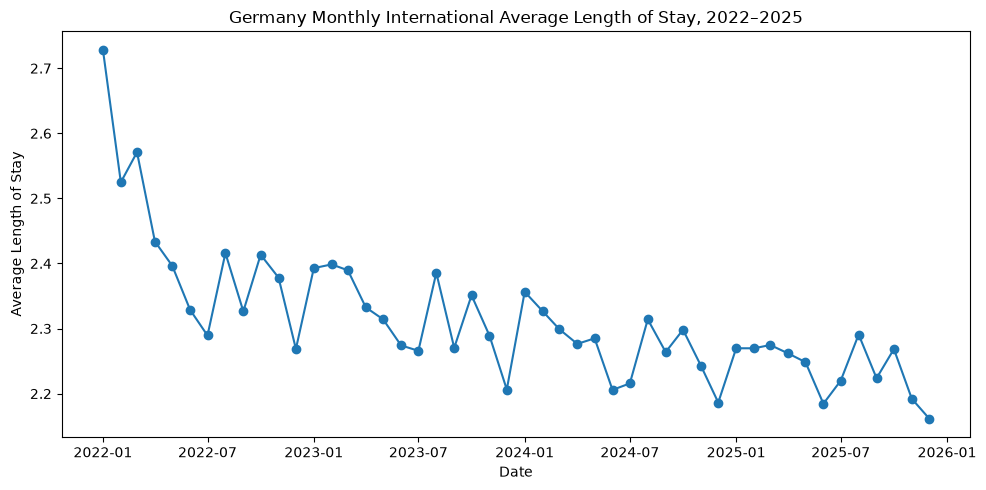

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_stay["date"],
    monthly_stay["avg_length_of_stay"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Average Length of Stay")
plt.title(
    "Germany Monthly International "
    "Average Length of Stay, 2022–2025"
)

plt.tight_layout()
plt.show()

In [7]:
trend_result = linregress(
    monthly_stay["time_index"],
    monthly_stay["avg_length_of_stay"]
)

print(
    f"Slope: {trend_result.slope:.6f}"
)

print(
    f"Intercept: {trend_result.intercept:.4f}"
)

print(
    f"R-squared: {trend_result.rvalue ** 2:.4f}"
)

print(
    f"Two-sided p-value: {trend_result.pvalue:.6f}"
)

print(
    f"Standard error: {trend_result.stderr:.6f}"
)

Slope: -0.005574
Intercept: 2.4452
R-squared: 0.5595
Two-sided p-value: 0.000000
Standard error: 0.000729


In [8]:
monthly_stay[
    "predicted_stay"
] = (
    trend_result.intercept
    +
    trend_result.slope
    * monthly_stay["time_index"]
)

monthly_stay[
    "residual"
] = (
    monthly_stay[
        "avg_length_of_stay"
    ]
    -
    monthly_stay[
        "predicted_stay"
    ]
)

monthly_stay[
    [
        "date",
        "avg_length_of_stay",
        "predicted_stay",
        "residual"
    ]
].head()

,date,avg_length_of_stay,predicted_stay,residual
0,2022-01-01,2.728406,2.445183,0.283223
1,2022-02-01,2.524823,2.439609,0.085214
2,2022-03-01,2.570980,2.434035,0.136946
3,2022-04-01,2.433739,2.428460,0.005279
4,2022-05-01,2.396439,2.422886,-0.026447


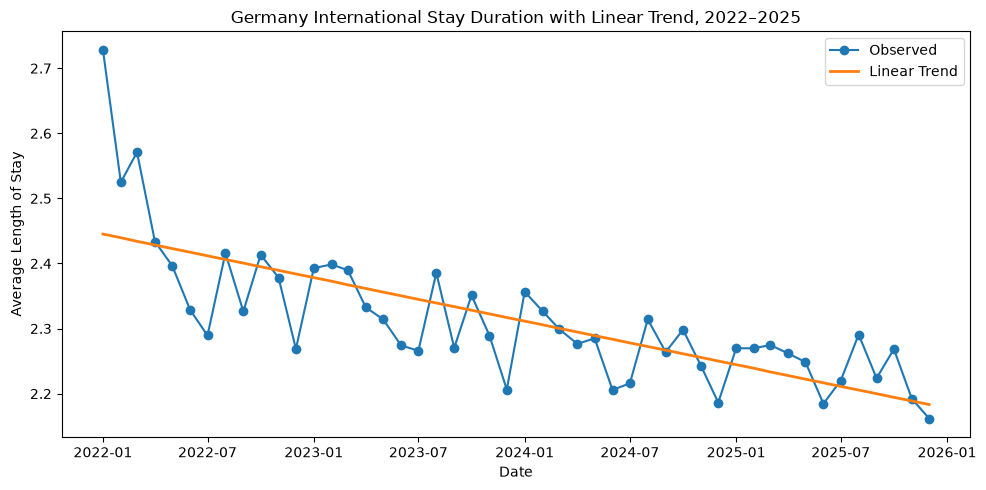

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_stay["date"],
    monthly_stay["avg_length_of_stay"],
    marker="o",
    label="Observed"
)

plt.plot(
    monthly_stay["date"],
    monthly_stay["predicted_stay"],
    linewidth=2,
    label="Linear Trend"
)

plt.xlabel("Date")
plt.ylabel("Average Length of Stay")
plt.title(
    "Germany International Stay Duration "
    "with Linear Trend, 2022–2025"
)

plt.legend()
plt.tight_layout()
plt.show()

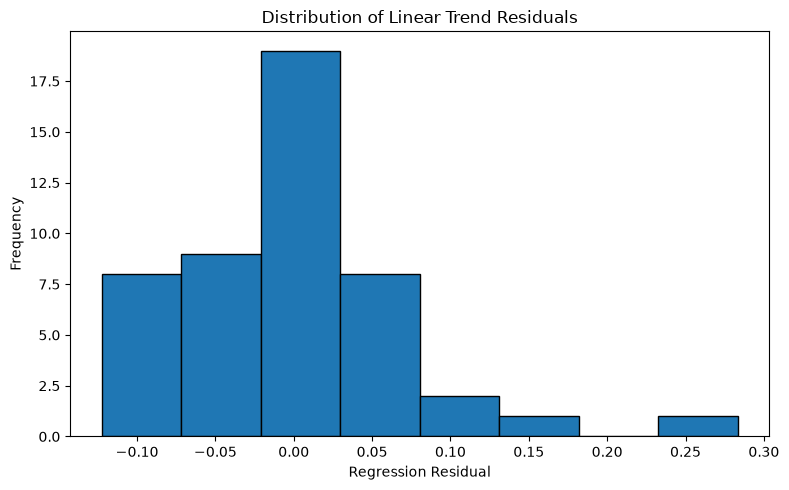

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    monthly_stay["residual"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("Regression Residual")
plt.ylabel("Frequency")
plt.title(
    "Distribution of Linear Trend Residuals"
)

plt.tight_layout()
plt.show()

In [11]:
shapiro_stat, shapiro_p = shapiro(
    monthly_stay["residual"]
)

print(
    f"Shapiro-Wilk statistic: "
    f"{shapiro_stat:.4f}"
)

print(
    f"Shapiro-Wilk p-value: "
    f"{shapiro_p:.6f}"
)

Shapiro-Wilk statistic: 0.9014
Shapiro-Wilk p-value: 0.000697


In [12]:
from statsmodels.stats.stattools import durbin_watson

In [13]:
dw_stat = durbin_watson(
    monthly_stay["residual"]
)

print(
    f"Durbin-Watson statistic: "
    f"{dw_stat:.4f}"
)

Durbin-Watson statistic: 1.1418


In [14]:
monthly_seasonality = (
    monthly_stay
    .groupby("month")
    .agg(
        mean_stay=(
            "avg_length_of_stay",
            "mean"
        ),
        std_stay=(
            "avg_length_of_stay",
            "std"
        ),
        observations=(
            "avg_length_of_stay",
            "size"
        )
    )
    .reset_index()
)

monthly_seasonality.round(3)

,month,mean_stay,std_stay,observations
0,1,2.437,0.201,4
1,2,2.380,0.110,4
2,3,2.384,0.134,4
3,4,2.326,0.078,4
4,5,2.311,0.063,4
5,6,2.248,0.066,4
6,7,2.248,0.036,4
7,8,2.352,0.059,4
8,9,2.271,0.042,4
9,10,2.333,0.064,4


### Assumption Assessment

The initial linear trend model indicates a negative relationship between time and Germany's international average length of stay.

The estimated unadjusted slope is approximately -0.00557 nights per month, equivalent to approximately -0.0669 nights per year. The simple time trend explains approximately 55.95% of the observed variation in monthly stay duration.

However, diagnostic testing indicates that ordinary least-squares inference should not be used without adjustment.

The Shapiro-Wilk test produced a p-value below 0.05, providing evidence that the regression residuals deviate from normality.

The Durbin-Watson statistic was approximately 1.14, indicating positive serial correlation among consecutive monthly residuals.

Average length of stay also varies systematically across calendar months, indicating recurring seasonal structure.

Because the data form a monthly time series with seasonality and serial dependence, the final inference will use a regression model controlling for calendar-month effects together with heteroskedasticity and autocorrelation-consistent (HAC) standard errors.

In [15]:
import statsmodels.formula.api as smf

In [16]:
seasonal_model = smf.ols(
    formula=(
        "avg_length_of_stay "
        "~ time_index + C(month)"
    ),
    data=monthly_stay
).fit()

print(
    seasonal_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:     avg_length_of_stay   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     12.94
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           1.55e-09
Time:                        20:02:23   Log-Likelihood:                 81.521
No. Observations:                  48   AIC:                            -137.0
Df Residuals:                      35   BIC:                            -112.7
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.5272      0.028     90.

In [17]:
monthly_stay[
    "seasonal_residual"
] = seasonal_model.resid

seasonal_dw = durbin_watson(
    monthly_stay[
        "seasonal_residual"
    ]
)

seasonal_shapiro_stat, seasonal_shapiro_p = shapiro(
    monthly_stay[
        "seasonal_residual"
    ]
)

print(
    f"Adjusted-model Durbin-Watson: "
    f"{seasonal_dw:.4f}"
)

print(
    f"Adjusted-model Shapiro-Wilk statistic: "
    f"{seasonal_shapiro_stat:.4f}"
)

print(
    f"Adjusted-model Shapiro-Wilk p-value: "
    f"{seasonal_shapiro_p:.6f}"
)

Adjusted-model Durbin-Watson: 0.7199
Adjusted-model Shapiro-Wilk statistic: 0.8456
Adjusted-model Shapiro-Wilk p-value: 0.000017


In [18]:
seasonal_hac = seasonal_model.get_robustcov_results(
    cov_type="HAC",
    maxlags=1
)

print(
    seasonal_hac.summary()
)

                            OLS Regression Results                            
Dep. Variable:     avg_length_of_stay   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     23.53
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           3.01e-13
Time:                        20:02:36   Log-Likelihood:                 81.521
No. Observations:                  48   AIC:                            -137.0
Df Residuals:                      35   BIC:                            -112.7
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.5272      0.066     38.

In [19]:
parameter_names = (
    seasonal_model
    .model
    .exog_names
)

time_position = (
    parameter_names
    .index("time_index")
)

trend_beta = (
    seasonal_hac.params[
        time_position
    ]
)

trend_se = (
    seasonal_hac.bse[
        time_position
    ]
)

trend_t = (
    seasonal_hac.tvalues[
        time_position
    ]
)

trend_p_two_sided = (
    seasonal_hac.pvalues[
        time_position
    ]
)

print(
    f"Adjusted monthly trend: "
    f"{trend_beta:.6f}"
)

print(
    f"HAC standard error: "
    f"{trend_se:.6f}"
)

print(
    f"Test statistic: "
    f"{trend_t:.4f}"
)

print(
    f"Two-sided p-value: "
    f"{trend_p_two_sided:.6f}"
)

print(
    f"Annualized trend: "
    f"{trend_beta * 12:.4f} nights/year"
)

Adjusted monthly trend: -0.005020
HAC standard error: 0.000689
Test statistic: -7.2821
Two-sided p-value: 0.000000
Annualized trend: -0.0602 nights/year


In [20]:
if trend_beta < 0:
    trend_p_one_sided = (
        trend_p_two_sided / 2
    )
else:
    trend_p_one_sided = (
        1 - trend_p_two_sided / 2
    )

print(
    f"One-sided p-value: "
    f"{trend_p_one_sided:.6f}"
)

One-sided p-value: 0.000000


In [21]:
alpha = 0.05

df_resid = (
    seasonal_model.df_resid
)

critical_t = stats.t.ppf(
    alpha,
    df=df_resid
)

print(
    f"Degrees of freedom: "
    f"{df_resid:.0f}"
)

print(
    f"Lower critical t-value: "
    f"{critical_t:.4f}"
)

print(
    f"Observed t-statistic: "
    f"{trend_t:.4f}"
)

Degrees of freedom: 35
Lower critical t-value: -1.6896
Observed t-statistic: -7.2821


In [22]:
trend_ci = (
    seasonal_hac
    .conf_int(
        alpha=0.05
    )[
        time_position
    ]
)

print(
    f"95% CI for monthly trend: "
    f"[{trend_ci[0]:.6f}, "
    f"{trend_ci[1]:.6f}]"
)

print(
    f"95% CI for annualized trend: "
    f"[{trend_ci[0] * 12:.4f}, "
    f"{trend_ci[1] * 12:.4f}] nights/year"
)

95% CI for monthly trend: [-0.006419, -0.003620]
95% CI for annualized trend: [-0.0770, -0.0434] nights/year


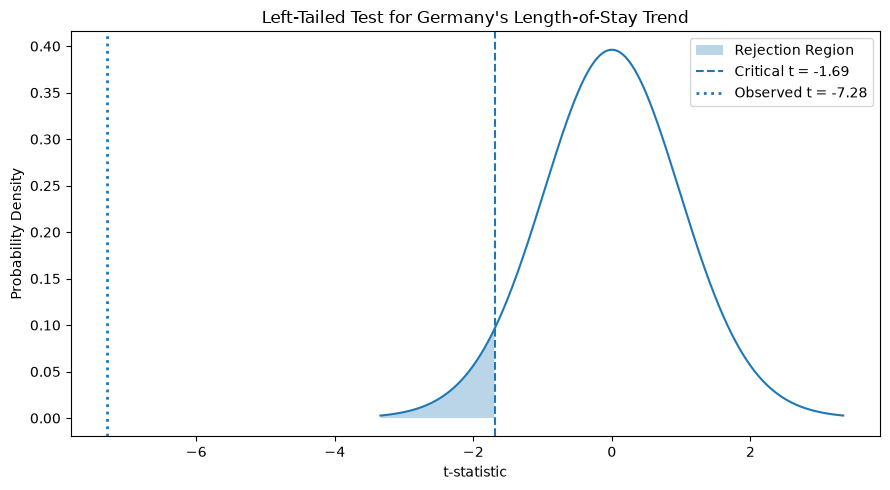

In [23]:
x = np.linspace(
    stats.t.ppf(
        0.001,
        df_resid
    ),
    stats.t.ppf(
        0.999,
        df_resid
    ),
    1000
)

y = stats.t.pdf(
    x,
    df_resid
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    x,
    y
)

plt.fill_between(
    x,
    0,
    y,
    where=(
        x <= critical_t
    ),
    alpha=0.3,
    label="Rejection Region"
)

plt.axvline(
    critical_t,
    linestyle="--",
    label=(
        f"Critical t = "
        f"{critical_t:.2f}"
    )
)

plt.axvline(
    trend_t,
    linestyle=":",
    linewidth=2,
    label=(
        f"Observed t = "
        f"{trend_t:.2f}"
    )
)

plt.xlabel("t-statistic")
plt.ylabel("Probability Density")

plt.title(
    "Left-Tailed Test for Germany's "
    "Length-of-Stay Trend"
)

plt.legend()
plt.tight_layout()
plt.show()

### Preliminary Result

After controlling for recurring calendar-month effects, Germany's international average length of stay retains a substantial negative time trend.

The estimated coefficient is approximately -0.00502 nights per month, equivalent to an annualized decline of approximately -0.0602 nights per year.

Using HAC standard errors with one lag, the observed test statistic is approximately -7.28, compared with a left-tailed critical value of approximately -1.69 at α = 0.05.

The corresponding one-sided p-value is below 0.05, and the 95% confidence interval for the annualized trend ranges from approximately -0.0770 to -0.0434 nights per year.

These initial results provide strong evidence of a declining stay-duration trend.

However, substantial positive serial dependence remains in the seasonality-adjusted residuals. Therefore, additional autocorrelation diagnostics and a sensitivity analysis using alternative HAC lag specifications are conducted before finalizing the hypothesis decision.

In [24]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

<Figure size 900x500 with 0 Axes>

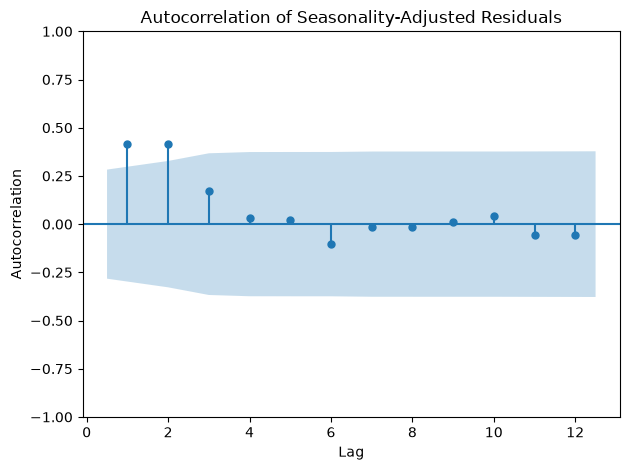

In [25]:
plt.figure(figsize=(9, 5))

plot_acf(
    monthly_stay["seasonal_residual"],
    lags=12,
    zero=False
)

plt.title(
    "Autocorrelation of Seasonality-Adjusted Residuals"
)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [26]:
ljung_box = acorr_ljungbox(
    monthly_stay["seasonal_residual"],
    lags=[1, 3, 6, 12],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
1,8.733312,0.003124
3,19.352377,0.000231
6,20.045287,0.002718
12,20.648683,0.055768


In [27]:
hac_results = []

for lag in [1, 3, 6, 12]:

    model_hac = (
        seasonal_model
        .get_robustcov_results(
            cov_type="HAC",
            maxlags=lag,
            use_correction=True
        )
    )

    position = (
        seasonal_model
        .model
        .exog_names
        .index("time_index")
    )

    hac_results.append({
        "maxlags": lag,
        "trend_beta": model_hac.params[position],
        "robust_se": model_hac.bse[position],
        "t_statistic": model_hac.tvalues[position],
        "two_sided_p": model_hac.pvalues[position]
    })

hac_sensitivity = pd.DataFrame(
    hac_results
)

hac_sensitivity[
    "one_sided_p"
] = (
    hac_sensitivity[
        "two_sided_p"
    ] / 2
)

hac_sensitivity[
    "annualized_trend"
] = (
    hac_sensitivity[
        "trend_beta"
    ] * 12
)

hac_sensitivity.round(6)

,maxlags,trend_beta,robust_se,t_statistic,two_sided_p,one_sided_p,annualized_trend
0,1,-0.00502,0.000807,-6.218283,0.000000,0.000000,-0.060236
1,3,-0.00502,0.000976,-5.143346,0.000010,0.000005,-0.060236
2,6,-0.00502,0.001016,-4.939666,0.000019,0.000010,-0.060236
3,12,-0.00502,0.000941,-5.335487,0.000006,0.000003,-0.060236


In [28]:
hac_ci_results = []

for lag in [1, 3, 6, 12]:

    model_hac = (
        seasonal_model
        .get_robustcov_results(
            cov_type="HAC",
            maxlags=lag,
            use_correction=True
        )
    )

    position = (
        seasonal_model
        .model
        .exog_names
        .index("time_index")
    )

    ci = (
        model_hac
        .conf_int(alpha=0.05)[position]
    )

    hac_ci_results.append({
        "maxlags": lag,
        "monthly_lower": ci[0],
        "monthly_upper": ci[1],
        "annual_lower": ci[0] * 12,
        "annual_upper": ci[1] * 12
    })

hac_confidence_intervals = pd.DataFrame(
    hac_ci_results
)

hac_confidence_intervals.round(4)

,maxlags,monthly_lower,monthly_upper,annual_lower,annual_upper
0,1,-0.0067,-0.0034,-0.0799,-0.0406
1,3,-0.0070,-0.0030,-0.0840,-0.0365
2,6,-0.0071,-0.0030,-0.0850,-0.0355
3,12,-0.0069,-0.0031,-0.0832,-0.0373


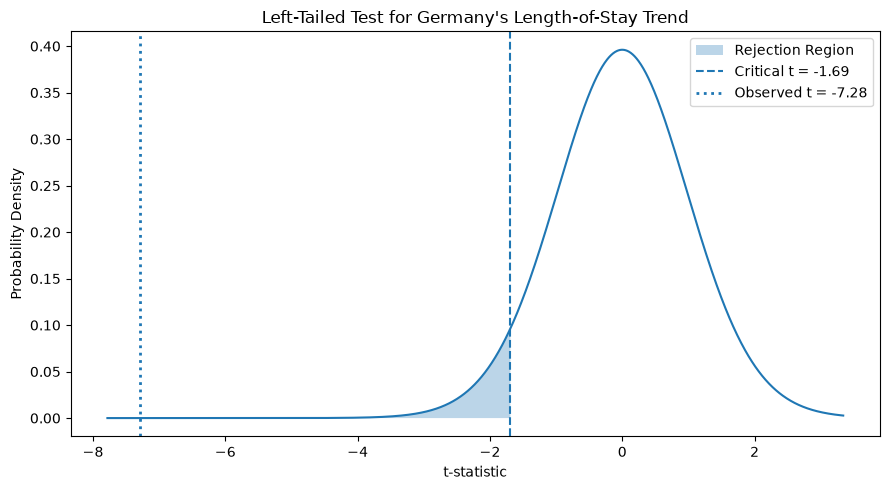

In [29]:
plot_left = min(
    trend_t - 0.5,
    stats.t.ppf(
        0.001,
        df_resid
    )
)

plot_right = stats.t.ppf(
    0.999,
    df_resid
)

x = np.linspace(
    plot_left,
    plot_right,
    1500
)

y = stats.t.pdf(
    x,
    df_resid
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    y
)

plt.fill_between(
    x,
    0,
    y,
    where=(x <= critical_t),
    alpha=0.3,
    label="Rejection Region"
)

plt.axvline(
    critical_t,
    linestyle="--",
    label=f"Critical t = {critical_t:.2f}"
)

plt.axvline(
    trend_t,
    linestyle=":",
    linewidth=2,
    label=f"Observed t = {trend_t:.2f}"
)

plt.xlabel("t-statistic")
plt.ylabel("Probability Density")

plt.title(
    "Left-Tailed Test for Germany's "
    "Length-of-Stay Trend"
)

plt.legend()
plt.tight_layout()
plt.show()

### Final Hypothesis Decision

Residual diagnostics confirmed positive serial dependence in the monthly time series. The Ljung-Box test identified statistically significant residual autocorrelation at several short-run lags.

To account for this dependence, the seasonality-adjusted regression was evaluated using heteroskedasticity and autocorrelation-consistent (HAC) standard errors across lag specifications of 1, 3, 6, and 12 months.

The estimated trend remained approximately -0.00502 nights per month under every specification, while all confidence intervals remained below zero and all one-sided p-values remained below α = 0.05.

Using HAC with three lags as the primary specification, the robust test statistic was approximately -5.14. This is below the left-tailed critical value of approximately -1.69.

Therefore, the null hypothesis is rejected.

There is statistically significant evidence that Germany's international average length of stay declined between January 2022 and December 2025, after controlling for recurring calendar-month differences and accounting for short-run serial dependence.

The estimated decline is approximately 0.0050 nights per month, equivalent to approximately 0.0602 nights, or about 1.45 hours, per year.

The 95% confidence interval indicates an annualized decline of approximately 0.0365 to 0.0840 nights per year.

The result describes a temporal relationship and should not be interpreted as evidence that the passage of time itself caused the decline.

In [30]:
final_hac = seasonal_model.get_robustcov_results(
    cov_type="HAC",
    maxlags=3,
    use_correction=True
)

time_position = (
    seasonal_model
    .model
    .exog_names
    .index("time_index")
)

final_beta = final_hac.params[time_position]
final_se = final_hac.bse[time_position]
final_t = final_hac.tvalues[time_position]
final_p_two = final_hac.pvalues[time_position]
final_p_one = final_p_two / 2

final_ci = final_hac.conf_int(
    alpha=0.05
)[time_position]

print(
    f"Final monthly trend: "
    f"{final_beta:.6f}"
)

print(
    f"Annualized trend: "
    f"{final_beta * 12:.4f} nights/year"
)

print(
    f"HAC(3) robust SE: "
    f"{final_se:.6f}"
)

print(
    f"Test statistic: "
    f"{final_t:.4f}"
)

print(
    f"One-sided p-value: "
    f"{final_p_one:.6f}"
)

print(
    "95% annualized CI: "
    f"[{final_ci[0] * 12:.4f}, "
    f"{final_ci[1] * 12:.4f}]"
)

Final monthly trend: -0.005020
Annualized trend: -0.0602 nights/year
HAC(3) robust SE: 0.000976
Test statistic: -5.1433
One-sided p-value: 0.000005
95% annualized CI: [-0.0840, -0.0365]


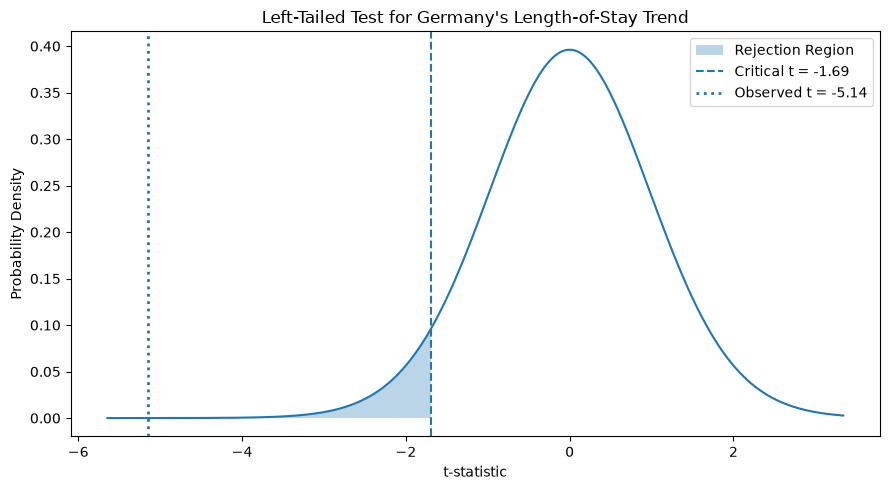

In [31]:
final_t_stat = final_t

plot_left = min(
    final_t_stat - 0.5,
    stats.t.ppf(
        0.001,
        df_resid
    )
)

plot_right = stats.t.ppf(
    0.999,
    df_resid
)

x = np.linspace(
    plot_left,
    plot_right,
    1500
)

y = stats.t.pdf(
    x,
    df_resid
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    y
)

plt.fill_between(
    x,
    0,
    y,
    where=(x <= critical_t),
    alpha=0.3,
    label="Rejection Region"
)

plt.axvline(
    critical_t,
    linestyle="--",
    label=f"Critical t = {critical_t:.2f}"
)

plt.axvline(
    final_t_stat,
    linestyle=":",
    linewidth=2,
    label=f"Observed t = {final_t_stat:.2f}"
)

plt.xlabel("t-statistic")
plt.ylabel("Probability Density")

plt.title(
    "Left-Tailed Test for Germany's "
    "Length-of-Stay Trend"
)

plt.legend()
plt.tight_layout()
plt.show()

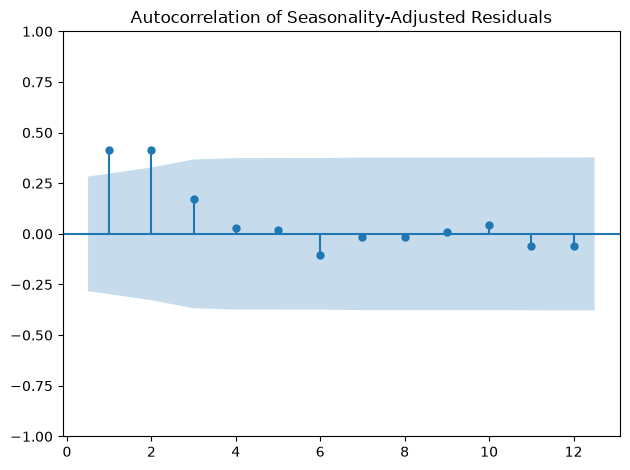

In [32]:
plot_acf(
    monthly_stay["seasonal_residual"],
    lags=12,
    zero=False
)

plt.title(
    "Autocorrelation of Seasonality-Adjusted Residuals"
)

plt.tight_layout()
plt.show()

### Statistical Test 2: Source-Market Scale and Average Length of Stay

**Research Question**

Is the size of an international source market associated with its average length of stay in Germany?

Market size is measured using total foreign overnight stays between 2021 and 2024. Average length of stay is calculated as total overnight stays divided by total arrivals over the same period.

The analysis focuses on published international source-market categories and excludes regional, EU, domestic, world, and residual aggregates to avoid double counting.

**Null Hypothesis (H₀)**  
There is no association between source-market size and average length of stay.

**Alternative Hypothesis (H₁)**  
There is an association between source-market size and average length of stay.

The significance level is:

**α = 0.05**

Because source markets differ substantially in scale and exploratory analysis identified unusual stay-duration observations, distributional assumptions and influential observations will be assessed before selecting the primary correlation method.

In [33]:
source_arrivals_stat = (
    source_arrivals[
        source_arrivals["international_market"]
        & source_arrivals["year"].between(2021, 2024)
        & source_arrivals["value_available"]
    ][
        [
            "source_market_code",
            "source_market",
            "market_type",
            "year",
            "foreign_arrivals"
        ]
    ]
)

source_nights_stat = (
    source_nights[
        source_nights["international_market"]
        & source_nights["year"].between(2021, 2024)
        & source_nights["value_available"]
    ][
        [
            "source_market_code",
            "source_market",
            "year",
            "foreign_nights"
        ]
    ]
)

source_market_stat = (
    source_arrivals_stat
    .merge(
        source_nights_stat,
        on=[
            "source_market_code",
            "source_market",
            "year"
        ],
        how="inner",
        validate="one_to_one"
    )
)

source_market_summary = (
    source_market_stat
    .groupby(
        [
            "source_market_code",
            "source_market",
            "market_type"
        ],
        as_index=False
    )
    .agg(
        total_arrivals=(
            "foreign_arrivals",
            "sum"
        ),
        total_nights=(
            "foreign_nights",
            "sum"
        )
    )
)

source_market_summary[
    "avg_length_of_stay"
] = (
    source_market_summary["total_nights"]
    /
    source_market_summary["total_arrivals"]
)

print(
    "Markets:",
    len(source_market_summary)
)

source_market_summary.head()

Markets: 41


,source_market_code,source_market,market_type,total_arrivals,total_nights,avg_length_of_stay
0,AT,Austria,individual_country,6692203.0,14002005.0,2.092286
1,AU,Australia,individual_country,878111.0,2129711.0,2.425332
2,BE,Belgium,individual_country,4701144.0,9996025.0,2.126296
3,BG,Bulgaria,individual_country,447459.0,1649238.0,3.685786
4,BR,Brazil,individual_country,703092.0,1861005.0,2.646887


In [34]:
print(
    source_market_summary[
        [
            "total_nights",
            "avg_length_of_stay"
        ]
    ].describe()
)

print(
    "\nMissing values:"
)

print(
    source_market_summary[
        [
            "total_nights",
            "avg_length_of_stay"
        ]
    ].isna().sum()
)

       total_nights  avg_length_of_stay
count  4.100000e+01           41.000000
mean   5.715746e+06            2.616806
std    7.672881e+06            0.598109
min    2.217370e+05            1.807792
25%    1.649238e+06            2.237701
50%    2.129711e+06            2.455384
75%    8.405040e+06            2.814164
max    3.825809e+07            4.156126

Missing values:
total_nights          0
avg_length_of_stay    0
dtype: int64


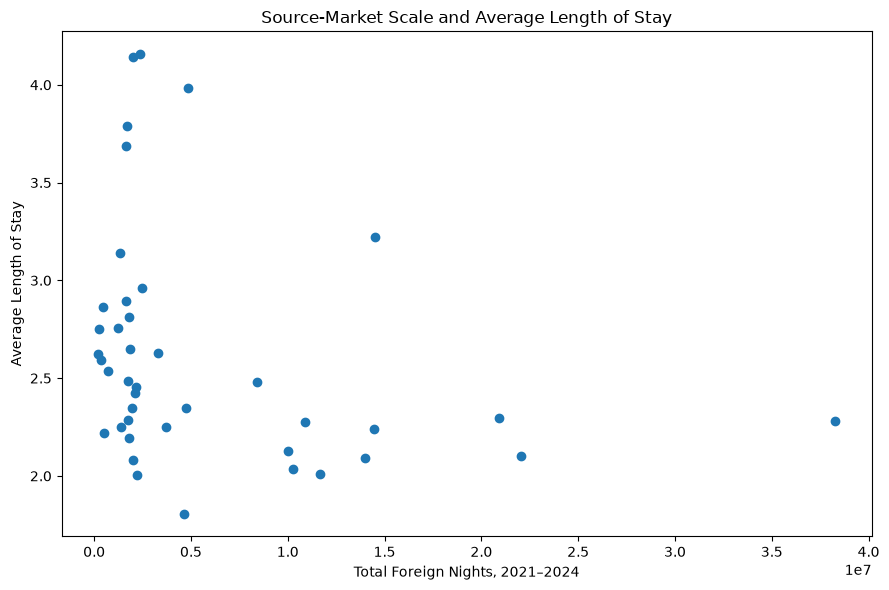

In [35]:
plt.figure(figsize=(9, 6))

plt.scatter(
    source_market_summary["total_nights"],
    source_market_summary["avg_length_of_stay"]
)

plt.xlabel(
    "Total Foreign Nights, 2021–2024"
)

plt.ylabel(
    "Average Length of Stay"
)

plt.title(
    "Source-Market Scale and "
    "Average Length of Stay"
)

plt.tight_layout()
plt.show()

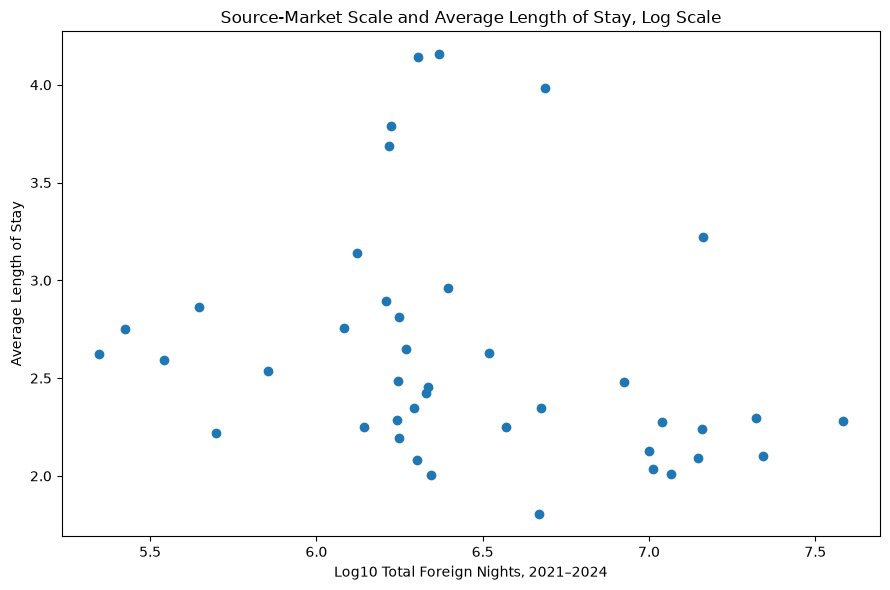

In [36]:
source_market_summary[
    "log_total_nights"
] = np.log10(
    source_market_summary[
        "total_nights"
    ]
)

plt.figure(figsize=(9, 6))

plt.scatter(
    source_market_summary[
        "log_total_nights"
    ],
    source_market_summary[
        "avg_length_of_stay"
    ]
)

plt.xlabel(
    "Log10 Total Foreign Nights, 2021–2024"
)

plt.ylabel(
    "Average Length of Stay"
)

plt.title(
    "Source-Market Scale and "
    "Average Length of Stay, Log Scale"
)

plt.tight_layout()
plt.show()

In [37]:
scale_shapiro = shapiro(
    source_market_summary[
        "total_nights"
    ]
)

stay_shapiro = shapiro(
    source_market_summary[
        "avg_length_of_stay"
    ]
)

print(
    "Total nights:"
)

print(
    f"Shapiro statistic: "
    f"{scale_shapiro.statistic:.4f}"
)

print(
    f"p-value: "
    f"{scale_shapiro.pvalue:.6f}"
)

print(
    "\nAverage length of stay:"
)

print(
    f"Shapiro statistic: "
    f"{stay_shapiro.statistic:.4f}"
)

print(
    f"p-value: "
    f"{stay_shapiro.pvalue:.6f}"
)

Total nights:
Shapiro statistic: 0.6783
p-value: 0.000000

Average length of stay:
Shapiro statistic: 0.8554
p-value: 0.000102


In [38]:
log_scale_shapiro = shapiro(
    source_market_summary[
        "log_total_nights"
    ]
)

print(
    f"Log total nights "
    f"Shapiro statistic: "
    f"{log_scale_shapiro.statistic:.4f}"
)

print(
    f"Log total nights p-value: "
    f"{log_scale_shapiro.pvalue:.6f}"
)

Log total nights Shapiro statistic: 0.9592
Log total nights p-value: 0.147618


In [39]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return q1, q3, iqr, lower, upper

In [40]:
(
    scale_q1,
    scale_q3,
    scale_iqr,
    scale_lower,
    scale_upper
) = iqr_bounds(
    source_market_summary[
        "total_nights"
    ]
)

scale_outliers = (
    source_market_summary[
        (
            source_market_summary[
                "total_nights"
            ] < scale_lower
        )
        |
        (
            source_market_summary[
                "total_nights"
            ] > scale_upper
        )
    ][
        [
            "source_market",
            "total_nights",
            "avg_length_of_stay"
        ]
    ]
    .sort_values(
        "total_nights",
        ascending=False
    )
)

print(
    f"Scale lower bound: "
    f"{scale_lower:,.0f}"
)

print(
    f"Scale upper bound: "
    f"{scale_upper:,.0f}"
)

scale_outliers

Scale lower bound: -8,484,465
Scale upper bound: 18,538,743


,source_market,total_nights,avg_length_of_stay
27,Netherlands,38258091.0,2.280216
6,Switzerland and Liechtenstein,22049586.0,2.101679
39,United States,20906710.0,2.296562


In [41]:
(
    stay_q1,
    stay_q3,
    stay_iqr,
    stay_lower,
    stay_upper
) = iqr_bounds(
    source_market_summary[
        "avg_length_of_stay"
    ]
)

stay_outliers = (
    source_market_summary[
        (
            source_market_summary[
                "avg_length_of_stay"
            ] < stay_lower
        )
        |
        (
            source_market_summary[
                "avg_length_of_stay"
            ] > stay_upper
        )
    ][
        [
            "source_market",
            "total_nights",
            "avg_length_of_stay"
        ]
    ]
    .sort_values(
        "avg_length_of_stay",
        ascending=False
    )
)

print(
    f"LOS lower bound: "
    f"{stay_lower:.2f}"
)

print(
    f"LOS upper bound: "
    f"{stay_upper:.2f}"
)

stay_outliers

LOS lower bound: 1.37
LOS upper bound: 3.68


,source_market,total_nights,avg_length_of_stay
35,Slovakia,2343656.0,4.156126
16,Croatia,2018174.0,4.141441
31,Romania,4866099.0,3.983802
34,Slovenia,1680061.0,3.791812
3,Bulgaria,1649238.0,3.685786


### Assumption Assessment

The distributional diagnostics indicate that a non-parametric correlation method is more appropriate for the primary analysis.

Total source-market overnight stays are strongly right-skewed, with a Shapiro-Wilk p-value below 0.05. Average length of stay also deviates significantly from normality.

A logarithmic transformation substantially improves the distribution of market size, with the log-transformed variable no longer showing significant evidence against normality at α = 0.05. However, average length of stay remains non-normal.

IQR analysis identified the Netherlands, Switzerland and Liechtenstein, and the United States as unusually large source markets. Slovakia, Croatia, Romania, Slovenia, and Bulgaria were identified as unusually long-stay markets.

These observations represent genuine published source-market characteristics and are therefore retained.

Because the variables are non-normal and contain influential observations, Spearman's rank correlation is selected as the primary statistical test. Pearson correlations using raw and log-transformed market size are retained as sensitivity analyses.

In [42]:
spearman_scale_stay = spearmanr(
    source_market_summary["total_nights"],
    source_market_summary["avg_length_of_stay"]
)

print(
    f"Spearman rho: "
    f"{spearman_scale_stay.statistic:.4f}"
)

print(
    f"Two-sided p-value: "
    f"{spearman_scale_stay.pvalue:.6f}"
)

Spearman rho: -0.3814
Two-sided p-value: 0.013888


In [43]:
pearson_raw = pearsonr(
    source_market_summary["total_nights"],
    source_market_summary["avg_length_of_stay"]
)

pearson_log = pearsonr(
    source_market_summary["log_total_nights"],
    source_market_summary["avg_length_of_stay"]
)

print("Pearson correlation - raw scale")

print(
    f"r = {pearson_raw.statistic:.4f}"
)

print(
    f"p-value = {pearson_raw.pvalue:.6f}"
)

print(
    "\nPearson correlation - log scale"
)

print(
    f"r = {pearson_log.statistic:.4f}"
)

print(
    f"p-value = {pearson_log.pvalue:.6f}"
)

Pearson correlation - raw scale
r = -0.2748
p-value = 0.082093

Pearson correlation - log scale
r = -0.2480
p-value = 0.118016


In [44]:
source_market_summary[
    "scale_outlier"
] = (
    source_market_summary[
        "total_nights"
    ] > scale_upper
)

source_market_summary[
    "stay_outlier"
] = (
    source_market_summary[
        "avg_length_of_stay"
    ] > stay_upper
)

source_market_summary[
    "any_outlier"
] = (
    source_market_summary[
        "scale_outlier"
    ]
    |
    source_market_summary[
        "stay_outlier"
    ]
)

print(
    source_market_summary[
        "any_outlier"
    ].value_counts()
)

any_outlier
False    33
True      8
Name: count, dtype: int64


In [45]:
non_outlier_markets = (
    source_market_summary[
        ~source_market_summary[
            "any_outlier"
        ]
    ]
)

spearman_without_outliers = spearmanr(
    non_outlier_markets["total_nights"],
    non_outlier_markets["avg_length_of_stay"]
)

print(
    "All markets"
)

print(
    f"rho = "
    f"{spearman_scale_stay.statistic:.4f}, "
    f"p = "
    f"{spearman_scale_stay.pvalue:.6f}"
)

print(
    "\nSensitivity analysis "
    "excluding IQR outliers"
)

print(
    f"Markets = "
    f"{len(non_outlier_markets)}"
)

print(
    f"rho = "
    f"{spearman_without_outliers.statistic:.4f}, "
    f"p = "
    f"{spearman_without_outliers.pvalue:.6f}"
)

All markets
rho = -0.3814, p = 0.013888

Sensitivity analysis excluding IQR outliers
Markets = 33
rho = -0.4181, p = 0.015462


In [46]:
n_markets = len(
    source_market_summary
)

spearman_rho = (
    spearman_scale_stay.statistic
)

spearman_t = (
    spearman_rho
    *
    np.sqrt(
        (n_markets - 2)
        /
        (1 - spearman_rho ** 2)
    )
)

spearman_df = (
    n_markets - 2
)

alpha = 0.05

lower_critical_t = stats.t.ppf(
    alpha / 2,
    df=spearman_df
)

upper_critical_t = stats.t.ppf(
    1 - alpha / 2,
    df=spearman_df
)

print(
    f"Sample size: {n_markets}"
)

print(
    f"Degrees of freedom: "
    f"{spearman_df}"
)

print(
    f"Spearman rho: "
    f"{spearman_rho:.4f}"
)

print(
    f"Approximate t-statistic: "
    f"{spearman_t:.4f}"
)

print(
    f"Lower critical value: "
    f"{lower_critical_t:.4f}"
)

print(
    f"Upper critical value: "
    f"{upper_critical_t:.4f}"
)

Sample size: 41
Degrees of freedom: 39
Spearman rho: -0.3814
Approximate t-statistic: -2.5763
Lower critical value: -2.0227
Upper critical value: 2.0227


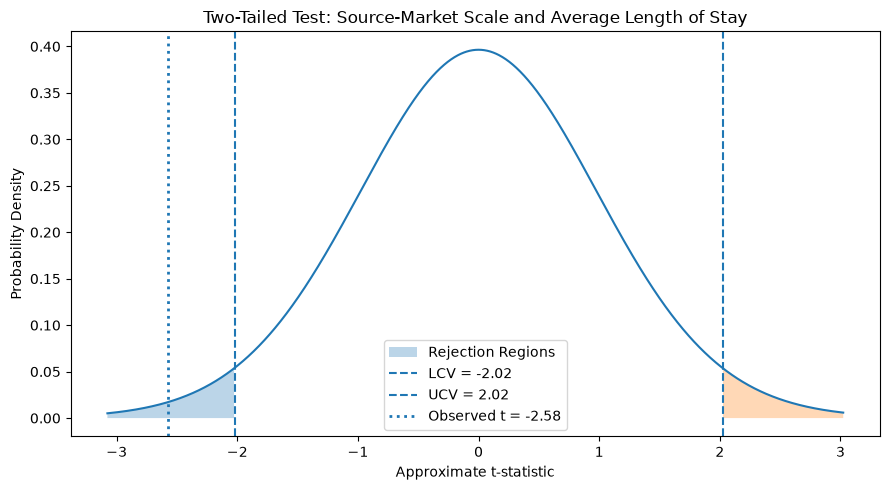

In [47]:
plot_left = min(
    lower_critical_t - 1,
    spearman_t - 0.5
)

plot_right = max(
    upper_critical_t + 1,
    spearman_t + 0.5
)

x = np.linspace(
    plot_left,
    plot_right,
    1500
)

y = stats.t.pdf(
    x,
    df=spearman_df
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    y
)

plt.fill_between(
    x,
    0,
    y,
    where=(x <= lower_critical_t),
    alpha=0.3,
    label="Rejection Regions"
)

plt.fill_between(
    x,
    0,
    y,
    where=(x >= upper_critical_t),
    alpha=0.3
)

plt.axvline(
    lower_critical_t,
    linestyle="--",
    label=(
        f"LCV = "
        f"{lower_critical_t:.2f}"
    )
)

plt.axvline(
    upper_critical_t,
    linestyle="--",
    label=(
        f"UCV = "
        f"{upper_critical_t:.2f}"
    )
)

plt.axvline(
    spearman_t,
    linestyle=":",
    linewidth=2,
    label=(
        f"Observed t = "
        f"{spearman_t:.2f}"
    )
)

plt.xlabel("Approximate t-statistic")
plt.ylabel("Probability Density")

plt.title(
    "Two-Tailed Test: Source-Market Scale "
    "and Average Length of Stay"
)

plt.legend()
plt.tight_layout()
plt.show()

### Final Hypothesis Decision

Spearman's rank correlation was selected as the primary statistical test because source-market scale and average length of stay were non-normal and contained influential observations.

The analysis produced a Spearman correlation coefficient of approximately -0.381, with a two-sided p-value of approximately 0.0139.

The corresponding approximate test statistic was -2.58, which falls below the lower critical value of approximately -2.02 at α = 0.05.

Therefore, the null hypothesis is rejected.

There is statistically significant evidence of a negative monotonic association between source-market scale and average length of stay in Germany.

This suggests that larger international source markets tend, on average, to be associated with somewhat shorter stays, while smaller markets are more likely to include longer-staying visitors.

The relationship is moderate rather than strong and should not be interpreted as causal.

Sensitivity analysis excluding all IQR-identified scale and stay-duration outliers produced a similar result, with Spearman's rho approximately -0.418 and p approximately 0.0155. This indicates that the conclusion is not driven solely by extreme observations.

Pearson correlations using raw and log-transformed market size were weaker and not statistically significant. This supports the use of Spearman's rank correlation as the more appropriate primary measure for the non-normal and heterogeneous source-market data.

### Statistical Test 3: Recent Source-Market Growth and Average Length of Stay

**Research Question**

Is recent source-market growth associated with average length of stay in Germany?

Recent market growth is measured as the percentage change in foreign overnight stays from 2023 to 2024. Average length of stay is measured using 2024 foreign overnight stays divided by 2024 foreign arrivals.

Using 2024 length of stay aligns the stay-duration measure with the endpoint of the 2023–2024 growth period.

**Null Hypothesis (H₀)**  
There is no association between recent source-market growth and average length of stay.

**Alternative Hypothesis (H₁)**  
There is an association between recent source-market growth and average length of stay.

The significance level is:

**α = 0.05**

Because recent market growth contains unusually high-growth observations and the distribution of stay duration may also be non-normal, statistical assumptions and influential observations will be assessed before selecting the primary correlation method.

In [48]:
growth_nights = (
    source_nights[
        source_nights["international_market"]
        & source_nights["year"].isin([2023, 2024])
        & source_nights["value_available"]
    ][
        [
            "source_market_code",
            "source_market",
            "year",
            "foreign_nights"
        ]
    ]
)

growth_wide = (
    growth_nights
    .pivot(
        index=[
            "source_market_code",
            "source_market"
        ],
        columns="year",
        values="foreign_nights"
    )
    .reset_index()
)

growth_wide.columns.name = None

growth_wide = growth_wide.rename(
    columns={
        2023: "nights_2023",
        2024: "nights_2024"
    }
)

growth_wide[
    "growth_2023_2024_pct"
] = (
    (
        growth_wide["nights_2024"]
        - growth_wide["nights_2023"]
    )
    /
    growth_wide["nights_2023"]
    * 100
)

growth_wide.head()

,source_market_code,source_market,nights_2023,nights_2024,growth_2023_2024_pct
0,AT,Austria,4155633.0,4360393.0,4.927288
1,AU,Australia,821361.0,811695.0,-1.176827
2,BE,Belgium,2939910.0,3044527.0,3.558510
3,BG,Bulgaria,461877.0,511086.0,10.654135
4,BR,Brazil,606200.0,661214.0,9.075223


In [49]:
arrivals_2024 = (
    source_arrivals[
        source_arrivals["international_market"]
        & (source_arrivals["year"] == 2024)
        & source_arrivals["value_available"]
    ][
        [
            "source_market_code",
            "source_market",
            "foreign_arrivals"
        ]
    ]
    .rename(
        columns={
            "foreign_arrivals":
            "arrivals_2024"
        }
    )
)

nights_2024 = (
    source_nights[
        source_nights["international_market"]
        & (source_nights["year"] == 2024)
        & source_nights["value_available"]
    ][
        [
            "source_market_code",
            "source_market",
            "foreign_nights"
        ]
    ]
    .rename(
        columns={
            "foreign_nights":
            "nights_2024"
        }
    )
)

los_2024 = (
    arrivals_2024
    .merge(
        nights_2024,
        on=[
            "source_market_code",
            "source_market"
        ],
        how="inner",
        validate="one_to_one"
    )
)

los_2024[
    "avg_length_of_stay_2024"
] = (
    los_2024["nights_2024"]
    /
    los_2024["arrivals_2024"]
)

los_2024.head()

,source_market_code,source_market,arrivals_2024,nights_2024,avg_length_of_stay_2024
0,BE,Belgium,1465552.0,3044527.0,2.077393
1,BG,Bulgaria,147766.0,511086.0,3.458752
2,CZ,Czechia,653394.0,1452153.0,2.222477
3,DK,Denmark,1529761.0,3051481.0,1.994744
4,EE,Estonia,75738.0,162994.0,2.152077


In [50]:
growth_stay = (
    growth_wide[
        [
            "source_market_code",
            "source_market",
            "nights_2023",
            "nights_2024",
            "growth_2023_2024_pct"
        ]
    ]
    .merge(
        los_2024[
            [
                "source_market_code",
                "source_market",
                "arrivals_2024",
                "avg_length_of_stay_2024"
            ]
        ],
        on=[
            "source_market_code",
            "source_market"
        ],
        how="inner",
        validate="one_to_one"
    )
)

print(
    "Markets:",
    len(growth_stay)
)

print(
    "\nMissing values:"
)

print(
    growth_stay[
        [
            "growth_2023_2024_pct",
            "avg_length_of_stay_2024"
        ]
    ].isna().sum()
)

growth_stay.head()

Markets: 41

Missing values:
growth_2023_2024_pct       0
avg_length_of_stay_2024    0
dtype: int64


,source_market_code,source_market,nights_2023,nights_2024,growth_2023_2024_pct,arrivals_2024,avg_length_of_stay_2024
0,AT,Austria,4155633.0,4360393.0,4.927288,2131281.0,2.045902
1,AU,Australia,821361.0,811695.0,-1.176827,336897.0,2.409327
2,BE,Belgium,2939910.0,3044527.0,3.558510,1465552.0,2.077393
3,BG,Bulgaria,461877.0,511086.0,10.654135,147766.0,3.458752
4,BR,Brazil,606200.0,661214.0,9.075223,255589.0,2.587021


In [51]:
growth_stay[
    [
        "growth_2023_2024_pct",
        "avg_length_of_stay_2024"
    ]
].describe()

,growth_2023_2024_pct,avg_length_of_stay_2024
count,41.000000,41.000000
mean,5.298394,2.458516
std,8.919731,0.429064
min,-21.017870,1.798669
25%,1.866048,2.152077
50%,4.217581,2.409327
75%,10.654135,2.587021
max,40.552819,3.462578


In [52]:
print("Fastest-growing markets")

display(
    growth_stay[
        [
            "source_market",
            "growth_2023_2024_pct",
            "avg_length_of_stay_2024"
        ]
    ]
    .sort_values(
        "growth_2023_2024_pct",
        ascending=False
    )
    .head(10)
)

print("\nLongest-stay markets")

display(
    growth_stay[
        [
            "source_market",
            "growth_2023_2024_pct",
            "avg_length_of_stay_2024"
        ]
    ]
    .sort_values(
        "avg_length_of_stay_2024",
        ascending=False
    )
    .head(10)
)

Fastest-growing markets


,source_market,growth_2023_2024_pct,avg_length_of_stay_2024
7,China,40.552819,2.167343
36,Türkiye,17.945975,2.510694
8,Cyprus,15.293049,2.579264
12,Greece,14.672726,2.756381
26,Malta,11.949387,2.503321
17,Hungary,11.632688,2.828008
21,Japan,11.579724,2.096424
19,Iceland,11.385989,2.644315
38,United Kingdom,10.880105,2.222397
39,United States,10.750402,2.241385



Longest-stay markets


,source_market,growth_2023_2024_pct,avg_length_of_stay_2024
35,Slovakia,-2.183924,3.462578
31,Romania,1.968993,3.461376
3,Bulgaria,10.654135,3.458752
16,Croatia,-3.984137,3.330073
34,Slovenia,-4.675240,3.107044
29,Poland,0.155626,2.832105
40,South Africa,-0.184495,2.829997
17,Hungary,11.632688,2.828008
12,Greece,14.672726,2.756381
19,Iceland,11.385989,2.644315


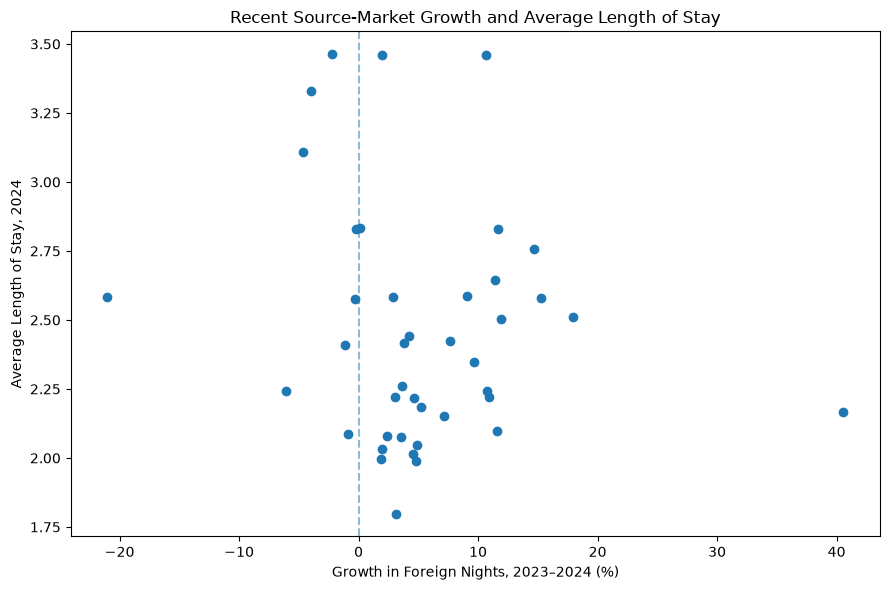

In [53]:
plt.figure(figsize=(9, 6))

plt.scatter(
    growth_stay["growth_2023_2024_pct"],
    growth_stay["avg_length_of_stay_2024"]
)

plt.axvline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.xlabel(
    "Growth in Foreign Nights, 2023–2024 (%)"
)

plt.ylabel(
    "Average Length of Stay, 2024"
)

plt.title(
    "Recent Source-Market Growth and "
    "Average Length of Stay"
)

plt.tight_layout()
plt.show()

In [54]:
growth_shapiro = shapiro(
    growth_stay[
        "growth_2023_2024_pct"
    ]
)

los_2024_shapiro = shapiro(
    growth_stay[
        "avg_length_of_stay_2024"
    ]
)

print("2023–2024 growth")

print(
    f"Shapiro statistic: "
    f"{growth_shapiro.statistic:.4f}"
)

print(
    f"p-value: "
    f"{growth_shapiro.pvalue:.6f}"
)

print(
    "\n2024 average length of stay"
)

print(
    f"Shapiro statistic: "
    f"{los_2024_shapiro.statistic:.4f}"
)

print(
    f"p-value: "
    f"{los_2024_shapiro.pvalue:.6f}"
)

2023–2024 growth
Shapiro statistic: 0.8732
p-value: 0.000294

2024 average length of stay
Shapiro statistic: 0.8983
p-value: 0.001480


In [55]:
(
    growth_q1,
    growth_q3,
    growth_iqr,
    growth_lower,
    growth_upper
) = iqr_bounds(
    growth_stay[
        "growth_2023_2024_pct"
    ]
)

growth_outliers = (
    growth_stay[
        (
            growth_stay[
                "growth_2023_2024_pct"
            ] < growth_lower
        )
        |
        (
            growth_stay[
                "growth_2023_2024_pct"
            ] > growth_upper
        )
    ][
        [
            "source_market",
            "growth_2023_2024_pct",
            "avg_length_of_stay_2024"
        ]
    ]
    .sort_values(
        "growth_2023_2024_pct",
        ascending=False
    )
)

print(
    f"Growth Q1: {growth_q1:.2f}%"
)

print(
    f"Growth Q3: {growth_q3:.2f}%"
)

print(
    f"Growth IQR: {growth_iqr:.2f}"
)

print(
    f"Growth lower bound: "
    f"{growth_lower:.2f}%"
)

print(
    f"Growth upper bound: "
    f"{growth_upper:.2f}%"
)

growth_outliers

Growth Q1: 1.87%
Growth Q3: 10.65%
Growth IQR: 8.79
Growth lower bound: -11.32%
Growth upper bound: 23.84%


,source_market,growth_2023_2024_pct,avg_length_of_stay_2024
7,China,40.552819,2.167343
32,Russia,-21.017870,2.583635


In [56]:
(
    los24_q1,
    los24_q3,
    los24_iqr,
    los24_lower,
    los24_upper
) = iqr_bounds(
    growth_stay[
        "avg_length_of_stay_2024"
    ]
)

los24_outliers = (
    growth_stay[
        (
            growth_stay[
                "avg_length_of_stay_2024"
            ] < los24_lower
        )
        |
        (
            growth_stay[
                "avg_length_of_stay_2024"
            ] > los24_upper
        )
    ][
        [
            "source_market",
            "growth_2023_2024_pct",
            "avg_length_of_stay_2024"
        ]
    ]
    .sort_values(
        "avg_length_of_stay_2024",
        ascending=False
    )
)

print(
    f"LOS Q1: {los24_q1:.2f}"
)

print(
    f"LOS Q3: {los24_q3:.2f}"
)

print(
    f"LOS IQR: {los24_iqr:.2f}"
)

print(
    f"LOS lower bound: "
    f"{los24_lower:.2f}"
)

print(
    f"LOS upper bound: "
    f"{los24_upper:.2f}"
)

los24_outliers

LOS Q1: 2.15
LOS Q3: 2.59
LOS IQR: 0.43
LOS lower bound: 1.50
LOS upper bound: 3.24


,source_market,growth_2023_2024_pct,avg_length_of_stay_2024
35,Slovakia,-2.183924,3.462578
31,Romania,1.968993,3.461376
3,Bulgaria,10.654135,3.458752
16,Croatia,-3.984137,3.330073


### Assumption Assessment

Both recent source-market growth and 2024 average length of stay deviate significantly from normality.

The Shapiro-Wilk test produced a p-value of approximately 0.0003 for 2023–2024 growth and approximately 0.0015 for 2024 average length of stay. Both are below α = 0.05.

IQR analysis identified China and Russia as unusual growth observations. China recorded exceptionally strong positive growth, while Russia recorded an unusually large decline.

Slovakia, Romania, Bulgaria, and Croatia were identified as unusually long-stay markets in 2024.

These observations represent valid published market characteristics and are retained in the primary analysis.

Because both variables are non-normal and contain influential observations, Spearman's rank correlation is selected as the primary statistical test. A sensitivity analysis excluding IQR-identified outliers will be used to evaluate the robustness of the result.

In [57]:
spearman_growth_stay = spearmanr(
    growth_stay["growth_2023_2024_pct"],
    growth_stay["avg_length_of_stay_2024"]
)

print(
    f"Spearman rho: "
    f"{spearman_growth_stay.statistic:.4f}"
)

print(
    f"Two-sided p-value: "
    f"{spearman_growth_stay.pvalue:.6f}"
)

Spearman rho: -0.0801
Two-sided p-value: 0.618431


In [63]:
rng = np.random.default_rng(42)

x_rank = stats.rankdata(
    source_market_summary["total_nights"].to_numpy()
)

y_rank = stats.rankdata(
    source_market_summary[
        "avg_length_of_stay"
    ].to_numpy()
)

observed_rho_test2 = np.corrcoef(
    x_rank,
    y_rank
)[0, 1]

n_permutations = 10000

permuted_rhos_test2 = np.empty(
    n_permutations
)

for i in range(n_permutations):
    permuted_rhos_test2[i] = np.corrcoef(
        x_rank,
        rng.permutation(y_rank)
    )[0, 1]

permutation_p_test2 = (
    np.sum(
        np.abs(permuted_rhos_test2)
        >= abs(observed_rho_test2)
    ) + 1
) / (
    n_permutations + 1
)

lower_critical_rho_test2 = np.quantile(
    permuted_rhos_test2,
    0.025
)

upper_critical_rho_test2 = np.quantile(
    permuted_rhos_test2,
    0.975
)

print(
    f"Observed Spearman rho: "
    f"{observed_rho_test2:.4f}"
)

print(
    f"Permutation p-value: "
    f"{permutation_p_test2:.6f}"
)

print(
    f"Lower critical rho: "
    f"{lower_critical_rho_test2:.4f}"
)

print(
    f"Upper critical rho: "
    f"{upper_critical_rho_test2:.4f}"
)

Observed Spearman rho: -0.3814
Permutation p-value: 0.015898
Lower critical rho: -0.3040
Upper critical rho: 0.3152


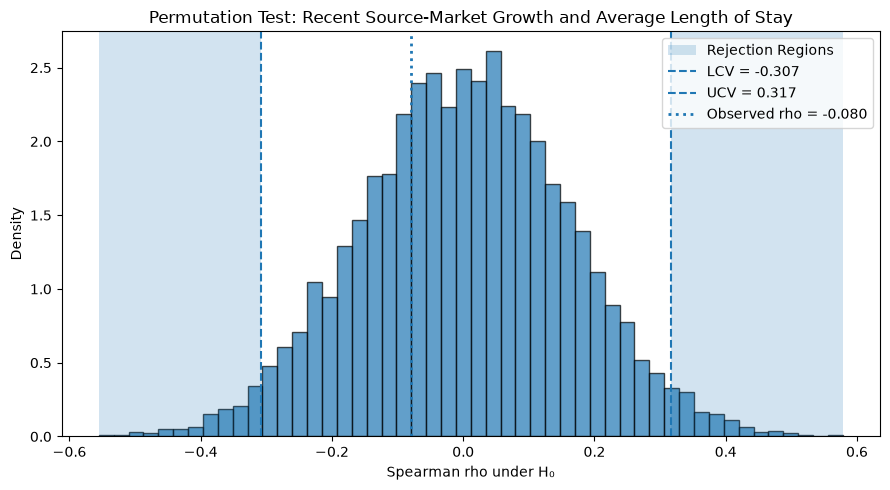

In [66]:
plt.figure(figsize=(9, 5))

plt.hist(
    permuted_rhos_test3,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

plt.axvspan(
    permuted_rhos_test3.min(),
    lower_critical_rho_test3,
    alpha=0.2,
    label="Rejection Regions"
)

plt.axvspan(
    upper_critical_rho_test3,
    permuted_rhos_test3.max(),
    alpha=0.2
)

plt.axvline(
    lower_critical_rho_test3,
    linestyle="--",
    label=(
        f"LCV = "
        f"{lower_critical_rho_test3:.3f}"
    )
)

plt.axvline(
    upper_critical_rho_test3,
    linestyle="--",
    label=(
        f"UCV = "
        f"{upper_critical_rho_test3:.3f}"
    )
)

plt.axvline(
    observed_rho_test3,
    linestyle=":",
    linewidth=2,
    label=(
        f"Observed rho = "
        f"{observed_rho_test3:.3f}"
    )
)

plt.xlabel("Spearman rho under H₀")
plt.ylabel("Density")

plt.title(
    "Permutation Test: Recent Source-Market Growth "
    "and Average Length of Stay"
)

plt.legend()
plt.tight_layout()
plt.show()

In [58]:
pearson_growth_stay = pearsonr(
    growth_stay["growth_2023_2024_pct"],
    growth_stay["avg_length_of_stay_2024"]
)

print(
    f"Pearson r: "
    f"{pearson_growth_stay.statistic:.4f}"
)

print(
    f"Two-sided p-value: "
    f"{pearson_growth_stay.pvalue:.6f}"
)

Pearson r: -0.1462
Two-sided p-value: 0.361716


In [59]:
growth_stay["growth_outlier"] = (
    (growth_stay["growth_2023_2024_pct"] < growth_lower)
    |
    (growth_stay["growth_2023_2024_pct"] > growth_upper)
)

growth_stay["los_outlier"] = (
    (growth_stay["avg_length_of_stay_2024"] < los24_lower)
    |
    (growth_stay["avg_length_of_stay_2024"] > los24_upper)
)

growth_stay["any_outlier"] = (
    growth_stay["growth_outlier"]
    |
    growth_stay["los_outlier"]
)

print(
    growth_stay["any_outlier"].value_counts()
)

any_outlier
False    35
True      6
Name: count, dtype: int64


In [60]:
growth_stay_non_outlier = (
    growth_stay[
        ~growth_stay["any_outlier"]
    ]
)

spearman_growth_sensitivity = spearmanr(
    growth_stay_non_outlier[
        "growth_2023_2024_pct"
    ],
    growth_stay_non_outlier[
        "avg_length_of_stay_2024"
    ]
)

print("Primary analysis")

print(
    f"rho = "
    f"{spearman_growth_stay.statistic:.4f}, "
    f"p = "
    f"{spearman_growth_stay.pvalue:.6f}"
)

print(
    "\nSensitivity analysis "
    "excluding IQR outliers"
)

print(
    f"Markets = "
    f"{len(growth_stay_non_outlier)}"
)

print(
    f"rho = "
    f"{spearman_growth_sensitivity.statistic:.4f}, "
    f"p = "
    f"{spearman_growth_sensitivity.pvalue:.6f}"
)

Primary analysis
rho = -0.0801, p = 0.618431

Sensitivity analysis excluding IQR outliers
Markets = 35
rho = 0.1398, p = 0.423226


In [65]:
rng = np.random.default_rng(42)

growth_rank = stats.rankdata(
    growth_stay[
        "growth_2023_2024_pct"
    ].to_numpy()
)

los2024_rank = stats.rankdata(
    growth_stay[
        "avg_length_of_stay_2024"
    ].to_numpy()
)

observed_rho_test3 = np.corrcoef(
    growth_rank,
    los2024_rank
)[0, 1]

n_permutations = 10000

permuted_rhos_test3 = np.empty(
    n_permutations
)

for i in range(n_permutations):
    permuted_rhos_test3[i] = np.corrcoef(
        growth_rank,
        rng.permutation(los2024_rank)
    )[0, 1]

permutation_p_test3 = (
    np.sum(
        np.abs(permuted_rhos_test3)
        >= abs(observed_rho_test3)
    ) + 1
) / (
    n_permutations + 1
)

lower_critical_rho_test3 = np.quantile(
    permuted_rhos_test3,
    0.025
)

upper_critical_rho_test3 = np.quantile(
    permuted_rhos_test3,
    0.975
)

print(
    f"Observed Spearman rho: "
    f"{observed_rho_test3:.4f}"
)

print(
    f"Permutation p-value: "
    f"{permutation_p_test3:.6f}"
)

print(
    f"Lower critical rho: "
    f"{lower_critical_rho_test3:.4f}"
)

print(
    f"Upper critical rho: "
    f"{upper_critical_rho_test3:.4f}"
)

Observed Spearman rho: -0.0801
Permutation p-value: 0.615138
Lower critical rho: -0.3075
Upper critical rho: 0.3169


### Final Hypothesis Decision

Spearman's rank correlation was selected as the primary statistical test because recent source-market growth and 2024 average length of stay were non-normal and contained influential but valid market observations.

The observed Spearman correlation was approximately -0.080, indicating a very weak negative monotonic association.

Permutation-based inference was used for the formal hypothesis decision. Using 10,000 reproducible permutations, the permutation p-value was approximately 0.615.

The empirical 95% null interval for Spearman's rho extended from approximately -0.308 to +0.317.

The observed correlation of -0.080 falls within these critical values and therefore lies within the non-rejection region.

Therefore, the null hypothesis is not rejected at α = 0.05.

There is insufficient statistical evidence of an association between source-market growth from 2023 to 2024 and average length of stay in Germany in 2024.

The sensitivity analysis supports this conclusion. After excluding the six IQR-identified outliers, the Spearman correlation changed direction from approximately -0.080 to +0.140 but remained weak and statistically non-significant. Pearson correlation also indicated a weak and non-significant relationship.

The change in direction after excluding outliers further suggests that there is no stable relationship between recent market growth and stay duration in this sample.

From a tourism strategy perspective, recent market growth and stay duration should therefore be treated as distinct dimensions of source-market performance. A rapidly growing market should not automatically be assumed to generate either longer or shorter stays.

This analysis identifies association rather than causation.

### Statistical Test 4: Change in Source-Market Foreign Nights

**Research Question**

Did international source markets generally experience a statistically significant change in foreign overnight stays in Germany from 2023 to 2024?

Because the same source markets are observed in both years, the analysis uses a paired-sample design.

**Null Hypothesis (H₀)**  
There is no systematic change in source-market foreign overnight stays between 2023 and 2024.

**Alternative Hypothesis (H₁)**  
There is a systematic change in source-market foreign overnight stays between 2023 and 2024.

The significance level is:

**α = 0.05**

The distribution of paired differences will be assessed before selecting the appropriate paired statistical test.

In [67]:
paired_nights = (
    growth_wide[
        [
            "source_market_code",
            "source_market",
            "nights_2023",
            "nights_2024"
        ]
    ]
    .dropna()
    .copy()
)

paired_nights["difference"] = (
    paired_nights["nights_2024"]
    - paired_nights["nights_2023"]
)

print(
    f"Paired markets: "
    f"{len(paired_nights)}"
)

print(
    "\nMissing values:"
)

print(
    paired_nights[
        [
            "nights_2023",
            "nights_2024",
            "difference"
        ]
    ].isna().sum()
)

paired_nights.head()

Paired markets: 41

Missing values:
nights_2023    0
nights_2024    0
difference     0
dtype: int64


,source_market_code,source_market,nights_2023,nights_2024,difference
0,AT,Austria,4155633.0,4360393.0,204760.0
1,AU,Australia,821361.0,811695.0,-9666.0
2,BE,Belgium,2939910.0,3044527.0,104617.0
3,BG,Bulgaria,461877.0,511086.0,49209.0
4,BR,Brazil,606200.0,661214.0,55014.0


In [68]:
paired_nights[
    [
        "nights_2023",
        "nights_2024",
        "difference"
    ]
].describe()

,nights_2023,nights_2024,difference
count,4.100000e+01,4.100000e+01,41.000000
mean,1.737436e+06,1.832024e+06,94587.292683
std,2.319118e+06,2.434166e+06,165465.519849
min,6.733400e+04,7.538000e+04,-74051.000000
25%,4.779480e+05,5.110860e+05,8046.000000
50%,6.412220e+05,6.959060e+05,31084.000000
75%,2.527064e+06,2.720461e+06,104617.000000
max,1.144863e+07,1.186761e+07,701207.000000


In [69]:
n_increased = (
    paired_nights["difference"] > 0
).sum()

n_decreased = (
    paired_nights["difference"] < 0
).sum()

n_unchanged = (
    paired_nights["difference"] == 0
).sum()

median_difference = (
    paired_nights["difference"].median()
)

total_difference = (
    paired_nights["difference"].sum()
)

print(
    f"Markets with increased nights: "
    f"{n_increased}"
)

print(
    f"Markets with decreased nights: "
    f"{n_decreased}"
)

print(
    f"Markets unchanged: "
    f"{n_unchanged}"
)

print(
    f"Median market-level change: "
    f"{median_difference:,.0f} nights"
)

print(
    f"Aggregate change across markets: "
    f"{total_difference:,.0f} nights"
)

Markets with increased nights: 32
Markets with decreased nights: 9
Markets unchanged: 0
Median market-level change: 31,084 nights
Aggregate change across markets: 3,878,079 nights


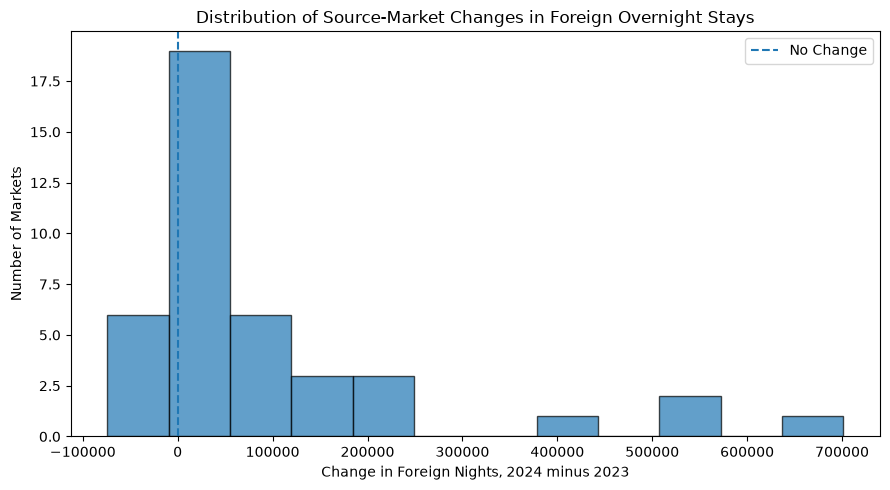

In [70]:
plt.figure(figsize=(9, 5))

plt.hist(
    paired_nights["difference"],
    bins=12,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--",
    label="No Change"
)

plt.xlabel(
    "Change in Foreign Nights, 2024 minus 2023"
)

plt.ylabel("Number of Markets")

plt.title(
    "Distribution of Source-Market Changes "
    "in Foreign Overnight Stays"
)

plt.legend()
plt.tight_layout()
plt.show()

In [71]:
difference_shapiro = shapiro(
    paired_nights["difference"]
)

print(
    f"Shapiro statistic: "
    f"{difference_shapiro.statistic:.4f}"
)

print(
    f"p-value: "
    f"{difference_shapiro.pvalue:.6f}"
)

Shapiro statistic: 0.6984
p-value: 0.000000


In [72]:
(
    diff_q1,
    diff_q3,
    diff_iqr,
    diff_lower,
    diff_upper
) = iqr_bounds(
    paired_nights["difference"]
)

difference_outliers = (
    paired_nights[
        (paired_nights["difference"] < diff_lower)
        |
        (paired_nights["difference"] > diff_upper)
    ][
        [
            "source_market",
            "nights_2023",
            "nights_2024",
            "difference"
        ]
    ]
    .sort_values(
        "difference",
        ascending=False
    )
)

print(
    f"Difference Q1: "
    f"{diff_q1:,.0f}"
)

print(
    f"Difference Q3: "
    f"{diff_q3:,.0f}"
)

print(
    f"Difference IQR: "
    f"{diff_iqr:,.0f}"
)

print(
    f"Lower bound: "
    f"{diff_lower:,.0f}"
)

print(
    f"Upper bound: "
    f"{diff_upper:,.0f}"
)

difference_outliers

Difference Q1: 8,046
Difference Q3: 104,617
Difference IQR: 96,571
Lower bound: -136,810
Upper bound: 249,474


,source_market,nights_2023,nights_2024,difference
39,United States,6522612.0,7223819.0,701207.0
7,China,1298292.0,1824786.0,526494.0
38,United Kingdom,4756526.0,5274041.0,517515.0
27,Netherlands,11448626.0,11867612.0,418986.0


In [73]:
difference_mean = (
    paired_nights["difference"].mean()
)

difference_median = (
    paired_nights["difference"].median()
)

difference_skew = stats.skew(
    paired_nights["difference"],
    bias=False
)

print(
    f"Mean difference: "
    f"{difference_mean:,.0f}"
)

print(
    f"Median difference: "
    f"{difference_median:,.0f}"
)

print(
    f"Skewness: "
    f"{difference_skew:.4f}"
)

Mean difference: 94,587
Median difference: 31,084
Skewness: 2.2946


### Assumption Assessment and Test Selection

The paired differences in foreign overnight stays between 2023 and 2024 were strongly non-normal.

The Shapiro-Wilk test produced a p-value below 0.001, providing strong evidence against normality of the paired differences.

The distribution was also strongly positively skewed, with skewness of approximately 2.29. The mean increase was approximately 94,587 nights per market, compared with a median increase of approximately 31,084 nights.

IQR analysis identified four unusually large positive changes: the United States, China, the United Kingdom, and the Netherlands.

Because the paired differences are strongly non-normal and asymmetric, a paired t-test is inappropriate as the primary test. The asymmetry also weakens the assumptions underlying the Wilcoxon signed-rank test.

Therefore, an exact two-sided sign test is selected as the primary inferential method.

The sign test evaluates whether increases and decreases are equally likely across the paired source markets without requiring normally distributed or symmetric differences.

In [74]:
sign_test = stats.binomtest(
    k=n_increased,
    n=n_increased + n_decreased,
    p=0.5,
    alternative="two-sided"
)

print(
    f"Markets included: "
    f"{n_increased + n_decreased}"
)

print(
    f"Markets increased: "
    f"{n_increased}"
)

print(
    f"Markets decreased: "
    f"{n_decreased}"
)

print(
    f"Observed increase proportion: "
    f"{sign_test.proportion_estimate:.4f}"
)

print(
    f"Exact two-sided p-value: "
    f"{sign_test.pvalue:.6f}"
)

Markets included: 41
Markets increased: 32
Markets decreased: 9
Observed increase proportion: 0.7805
Exact two-sided p-value: 0.000431


In [75]:
n_sign = (
    n_increased
    + n_decreased
)

alpha = 0.05

possible_counts = np.arange(
    0,
    n_sign + 1
)

lower_tail = stats.binom.cdf(
    possible_counts,
    n_sign,
    0.5
)

upper_tail = stats.binom.sf(
    possible_counts - 1,
    n_sign,
    0.5
)

lower_candidates = possible_counts[
    lower_tail <= alpha / 2
]

upper_candidates = possible_counts[
    upper_tail <= alpha / 2
]

lower_critical_sign = (
    lower_candidates.max()
)

upper_critical_sign = (
    upper_candidates.min()
)

print(
    f"Lower critical count: "
    f"{lower_critical_sign}"
)

print(
    f"Upper critical count: "
    f"{upper_critical_sign}"
)

print(
    f"Observed increases: "
    f"{n_increased}"
)

Lower critical count: 13
Upper critical count: 28
Observed increases: 32


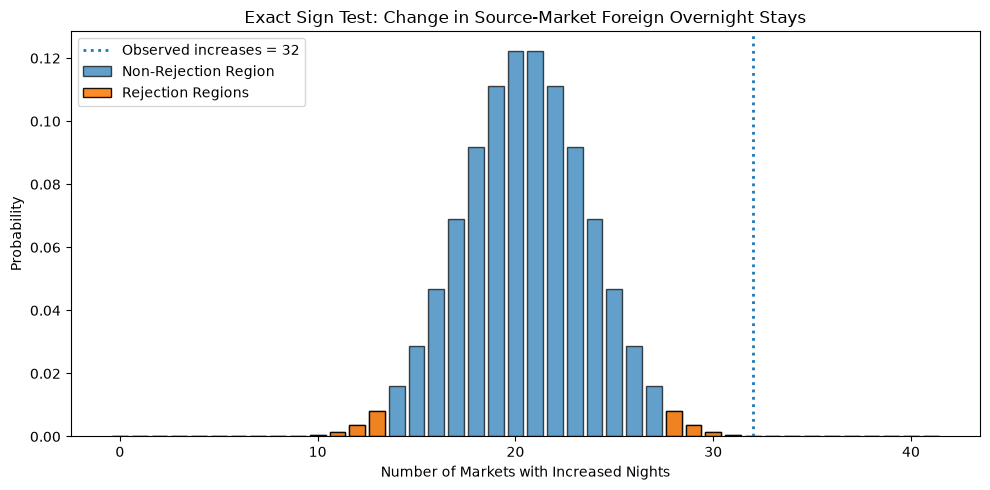

In [76]:
x_sign = np.arange(
    0,
    n_sign + 1
)

pmf_sign = stats.binom.pmf(
    x_sign,
    n_sign,
    0.5
)

plt.figure(figsize=(10, 5))

plt.bar(
    x_sign,
    pmf_sign,
    alpha=0.7,
    edgecolor="black",
    label="Non-Rejection Region"
)

rejection_mask = (
    (x_sign <= lower_critical_sign)
    |
    (x_sign >= upper_critical_sign)
)

plt.bar(
    x_sign[rejection_mask],
    pmf_sign[rejection_mask],
    alpha=0.9,
    edgecolor="black",
    label="Rejection Regions"
)

plt.axvline(
    n_increased,
    linestyle=":",
    linewidth=2,
    label=(
        f"Observed increases = "
        f"{n_increased}"
    )
)

plt.xlabel(
    "Number of Markets with Increased Nights"
)

plt.ylabel("Probability")

plt.title(
    "Exact Sign Test: Change in Source-Market "
    "Foreign Overnight Stays"
)

plt.legend()
plt.tight_layout()
plt.show()

In [77]:
increase_ci = sign_test.proportion_ci(
    confidence_level=0.95,
    method="exact"
)

print(
    f"Observed increase proportion: "
    f"{sign_test.proportion_estimate:.4f}"
)

print(
    f"95% exact confidence interval: "
    f"[{increase_ci.low:.4f}, "
    f"{increase_ci.high:.4f}]"
)

Observed increase proportion: 0.7805
95% exact confidence interval: [0.6239, 0.8944]


In [78]:
increase_proportion = (
    n_increased / n_sign
)

proportion_difference = (
    increase_proportion - 0.5
)

print(
    f"Increase proportion: "
    f"{increase_proportion:.4f}"
)

print(
    f"Difference from 50% null benchmark: "
    f"{proportion_difference:.4f}"
)

Increase proportion: 0.7805
Difference from 50% null benchmark: 0.2805


### Final Hypothesis Decision

An exact two-sided sign test was selected because the paired changes in foreign overnight stays were strongly non-normal and highly asymmetric.

Of the 41 eligible published international source-market categories, 32 recorded an increase in foreign overnight stays from 2023 to 2024, while 9 recorded a decrease. No markets were unchanged.

Approximately 78.05% of the analyzed source-market categories therefore experienced an increase. The 95% exact confidence interval for this proportion ranged from approximately 62.39% to 89.44%.

Under the null hypothesis that increases and decreases are equally likely, the number of increases follows a binomial distribution with n = 41 and p = 0.50.

The exact two-sided sign test produced a p-value of approximately 0.00043.

At α = 0.05, the exact rejection regions were 13 or fewer increases and 28 or more increases. The observed count of 32 increases lies within the upper rejection region.

Therefore, the null hypothesis is rejected.

There is statistically significant evidence that increases in foreign overnight stays were more common than decreases across the eligible published international source-market categories between 2023 and 2024.

The observed proportion of markets increasing was approximately 28.05 percentage points above the 50% null benchmark.

The median market-level change was an increase of approximately 31,084 overnight stays. Across the analyzed categories, the aggregate descriptive increase was approximately 3.88 million overnight stays.

The statistical result should be interpreted as evidence of a broad-based pattern across source markets rather than as a measure of Germany's total tourism growth. The sign test evaluates the direction of market-level changes and does not weight markets by their size.

The result describes a year-over-year pattern and does not establish causation.

## Statistical Analysis Summary

The statistical analysis examined four complementary dimensions of Germany's international tourism performance: changes in average length of stay over time, the relationship between source-market scale and stay duration, the relationship between recent market growth and stay duration, and the breadth of source-market growth.

### Key Findings

**1. Germany's international average length of stay is declining.**

After controlling for recurring calendar-month differences and accounting for short-run serial dependence using HAC robust standard errors, Germany's international average length of stay showed a statistically significant downward trend from January 2022 to December 2025.

The estimated decline was approximately 0.060 nights, or about 1.45 hours, per year.

**2. Larger source markets tend to have somewhat shorter stays.**

Across the 41 eligible published international source-market categories analyzed for 2021–2024, source-market scale showed a statistically significant negative monotonic association with average length of stay.

Spearman's rho was approximately -0.381, with a permutation p-value of approximately 0.0159.

The relationship was not strong enough to suggest that market size determines stay duration, but it indicates that scale and market depth should be evaluated separately.

**3. Recent source-market growth is not associated with longer stays.**

Growth in foreign overnight stays between 2023 and 2024 showed no statistically significant association with average length of stay in 2024.

Spearman's rho was approximately -0.080, with a permutation p-value of approximately 0.615.

This indicates that rapidly growing source markets were not systematically associated with either longer or shorter stays.

**4. Source-market growth between 2023 and 2024 was broad-based.**

Thirty-two of the 41 eligible published international source-market categories recorded an increase in foreign overnight stays between 2023 and 2024.

This represented approximately 78.05% of the analyzed markets, with a 95% exact confidence interval of approximately 62.39% to 89.44%.

The exact sign test produced a p-value of approximately 0.00043, providing statistically significant evidence that increases were more common than decreases across the analyzed source markets.

### Overall Interpretation

The results reveal an important distinction between tourism growth and tourism depth.

Germany experienced broad-based growth across international source markets, but recent market growth was not associated with longer stays. At the same time, average length of stay continued to decline, and larger source markets tended to have somewhat shorter stays.

These findings suggest that increasing visitor volume alone may not address Germany's stay-duration challenge.

Tourism competitiveness should therefore be evaluated across multiple dimensions, including:

- visitor and overnight-stay volume
- source-market scale
- source-market growth
- average length of stay
- seasonality
- market composition
- economic contribution

The statistical findings identify associations and temporal patterns rather than causal relationships. Strategic recommendations should therefore combine these results with the EU benchmarking, source-market, economic, and 2026 year-to-date analyses developed in the subsequent notebooks.